In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import insightface as i
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image
from insightface.utils import face_align
from faiss import IndexFlatL2
from onnxruntime import InferenceSession


In [2]:
# réduire det_size pour coller à la taille réelle des images 
face_analysis = FaceAnalysis(name="buffalo_l")
face_analysis.prepare(ctx_id=-1, det_size=(320, 320))


In [3]:
def detect_face(image_path, img_size=250):
    """
    Charge une image, détecte le(s) visage(s), et retourne le visage principal
    (le plus proche du centre de l'image si plusieurs sont détectés).
    
    Retourne : (img_rgb, face) ou (img_rgb, None) si aucun visage détecté
    """
    img2 = cv2.imread(image_path)
    if img2 is None:
        print(f"Impossible de charger : {image_path}")
        return None, None
    
    img_rgb2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    faces = face_analysis.get(img_rgb2)
    
    if len(faces) == 0:
        return img_rgb2, None
    
    if len(faces) == 1:
        return img_rgb2, faces[0]
    
    # plusieurs visages détectés → on prend celui le plus proche du centre
    center = img_size / 2
    def distance_to_center(face):
        x1, y1, x2, y2 = face.bbox
        face_center_x = (x1 + x2) / 2
        face_center_y = (y1 + y2) / 2
        return (face_center_x - center) ** 2 + (face_center_y - center) ** 2
    
    best_face = min(faces, key=distance_to_center)
    return img_rgb2, best_face

e:\Reconnaisance_faciale\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


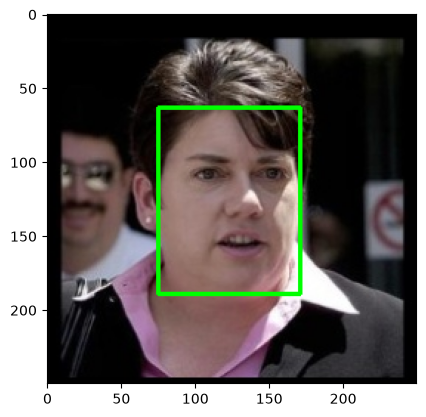

In [4]:
img_rgb, face = detect_face("data\\raw\\lfw_funneled\\Leslie_Caldwell\\Leslie_Caldwell_0002.jpg")

if face is not None:
    bbox = face.bbox.astype(int)
    cv2.rectangle(img_rgb, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 2)
    plt.imshow(img_rgb)
    plt.show()
else:
    print("Aucun visage détecté")

In [5]:
a = face.embedding
a

array([ 1.00111437e+00, -1.75919235e-01,  1.15883484e-01,  3.62120539e-01,
       -1.15226090e+00, -6.05421066e-01, -5.27312338e-01, -4.30450857e-01,
        5.71905017e-01,  1.03002632e+00, -9.55251694e-01, -1.64452457e+00,
        5.17065585e-01,  1.00838494e+00, -1.77178347e+00,  6.99143231e-01,
       -5.40571153e-01, -1.94455934e+00, -1.36665547e+00, -1.24753881e+00,
        3.95998538e-01, -6.93120182e-01,  8.43376577e-01, -5.19627750e-01,
        1.07187057e+00,  7.42458820e-01,  1.61616504e-03, -8.98708701e-02,
       -8.94804955e-01,  8.58648360e-01, -1.33353209e+00, -3.84359360e-01,
       -5.81822276e-01,  2.28607491e-01, -1.41176033e+00, -1.24054730e+00,
        8.75253618e-01, -2.89601982e-01, -1.52121019e+00,  1.38018095e+00,
       -2.74721503e-01, -4.52393204e-01, -1.17542529e+00, -8.56555462e-01,
       -7.45994091e-01,  1.06868148e+00,  8.38062167e-01, -7.58552730e-01,
       -1.98610342e+00,  2.50409335e-01, -4.24126238e-02, -1.60586894e+00,
        1.40070367e+00, -

In [6]:
b = face.normed_embedding
b

array([ 4.42992486e-02, -7.78441504e-03,  5.12783695e-03,  1.60238110e-02,
       -5.09874746e-02, -2.67898440e-02, -2.33335383e-02, -1.90474242e-02,
        2.53067613e-02,  4.55785990e-02, -4.22698297e-02, -7.27701113e-02,
        2.28801202e-02,  4.46209721e-02, -7.84013122e-02,  3.09370439e-02,
       -2.39202399e-02, -8.60466287e-02, -6.04744181e-02, -5.52035160e-02,
        1.75229106e-02, -3.06705255e-02,  3.73193622e-02, -2.29934957e-02,
        4.74302061e-02,  3.28537561e-02,  7.15152055e-05, -3.97678046e-03,
       -3.95950638e-02,  3.79951373e-02, -5.90087138e-02, -1.70078781e-02,
       -2.57456005e-02,  1.01158675e-02, -6.24703057e-02, -5.48941419e-02,
        3.87299173e-02, -1.28148701e-02, -6.73134550e-02,  6.10729232e-02,
       -1.21564092e-02, -2.00183708e-02, -5.20124957e-02, -3.79025266e-02,
       -3.30101922e-02,  4.72890884e-02,  3.70841995e-02, -3.35659124e-02,
       -8.78849551e-02,  1.10805975e-02, -1.87675597e-03, -7.10595995e-02,
        6.19810522e-02, -

In [7]:
a.shape

(512,)

In [8]:
b.shape

(512,)

In [9]:
def get_embedding(image_path):
    """
    Charge une image, détecte le visage principal et retourne son embedding.
    
    Retourne : embedding ou None si aucun visage détecté
    """
    img_rgb, face = detect_face(image_path)
    if face is None:
        return None
    return face.normed_embedding


In [10]:
def cosine_similarity(embedding1, embedding2):
    """Similarité cosinus entre 2 embeddings normalisés (produit scalaire)."""
    return np.dot(embedding1, embedding2)


def compare_faces(image_path1, image_path2, verbose=True):
    """
    Compare deux visages et retourne leur score de similarité.
    Retourne None si un visage n'a pas pu être détecté sur l'une des images.
    """
    embedding1 = get_embedding(image_path1)
    embedding2 = get_embedding(image_path2)

    if embedding1 is None or embedding2 is None:
        if verbose:
            print("Impossible de comparer : visage non détecté sur au moins une image.")
        return None

    score = cosine_similarity(embedding1, embedding2)

    if verbose:
        print(f"Similarité : {score:.4f}")

    return score

In [11]:
# --- Fix 2 : cache des embeddings déjà calculés ---
embedding_cache = {}

def get_embedding_cached(image_path):
    if image_path in embedding_cache:
        return embedding_cache[image_path]
    embedding = get_embedding(image_path)
    embedding_cache[image_path] = embedding
    return embedding


def compare_faces_cached(image_path1, image_path2, verbose=True):
    embedding1 = get_embedding_cached(image_path1)
    embedding2 = get_embedding_cached(image_path2)

    if embedding1 is None or embedding2 is None:
        if verbose:
            print("Impossible de comparer : visage non détecté sur au moins une image.")
        return None

    score = cosine_similarity(embedding1, embedding2)
    if verbose:
        print(f"Similarité : {score:.4f}")
    return score

In [12]:
compare_faces(
    "data\\raw\\lfw_funneled\\Leslie_Caldwell\\Leslie_Caldwell_0002.jpg",
    "data\\raw\\lfw_funneled\\Leslie_Caldwell\\Leslie_Caldwell_0003.jpg"
)

compare_faces(
    "data\\raw\\lfw_funneled\\Juliette_Lewis\\Juliette_Lewis_0001.jpg",
    "data\\raw\\lfw_funneled\\Arthur_Martinez\\Arthur_Martinez_0001.jpg"
)

compare_faces(
    "data\\raw\\lfw_funneled\\Jo_Joong-hyon\\Jo_Joong-hyon_0001.jpg",
    "data\\raw\\lfw_funneled\\Mathias_Reichhold\\Mathias_Reichhold_0003.jpg"
)

compare_faces(
    "data\\raw\\lfw_funneled\\Lon_Kruger\\Lon_Kruger_0001.jpg",
    "data\\raw\\lfw_funneled\\Lon_Kruger\\Lon_Kruger_0002.jpg"
)

Similarité : 0.6998
Similarité : -0.0220
Similarité : -0.1162
Similarité : 0.7188


np.float32(0.7188469)

In [13]:
df = pd.read_csv("data\\pairs\\positive_pairs.csv")
de = pd.read_csv("data\\pairs\\negative_pairs.csv")
display(df.head())
display(de.head())

,image1,image2
0,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...
1,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...
2,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...,data\raw\lfw_funneled\Aaron_Peirsol\Aaron_Peir...
3,data\raw\lfw_funneled\Aaron_Sorkin\Aaron_Sorki...,data\raw\lfw_funneled\Aaron_Sorkin\Aaron_Sorki...
4,data\raw\lfw_funneled\Abdel_Nasser_Assidi\Abde...,data\raw\lfw_funneled\Abdel_Nasser_Assidi\Abde...


,image1,image2
0,data\raw\lfw_funneled\Bill_Herrion\Bill_Herrio...,data\raw\lfw_funneled\Pedro_Martinez\Pedro_Mar...
1,data\raw\lfw_funneled\Mike_Duke\Mike_Duke_0001...,data\raw\lfw_funneled\Antonio_Catania\Antonio_...
2,data\raw\lfw_funneled\Heather_Willson\Heather_...,data\raw\lfw_funneled\Alexandra_Pelosi\Alexand...
3,data\raw\lfw_funneled\Joschka_Fischer\Joschka_...,data\raw\lfw_funneled\Greg_Hennigar\Greg_Henni...
4,data\raw\lfw_funneled\Cuba_Gooding_Jr\Cuba_Goo...,data\raw\lfw_funneled\Anwar_Ibrahim\Anwar_Ibra...


In [14]:
# --- Boucle avec tqdm pour suivre la progression ---
from tqdm import tqdm

positive_scores = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Paires positives"):
    score = compare_faces_cached(row['image1'], row['image2'], verbose=False)
    if score is not None:
        positive_scores.append(score)

negative_scores = []
for _, row in tqdm(de.iterrows(), total=len(de), desc="Paires négatives"):
    score = compare_faces_cached(row['image1'], row['image2'], verbose=False)
    if score is not None:
        negative_scores.append(score)

Paires positives:   0%|          | 0/3482 [00:00<?, ?it/s]e:\Reconnaisance_faciale\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Paires négatives:   0%|          | 0/3482 [00:00<?, ?it/s]e:\Reconnaisance_faciale\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Paires négatives: 100%|██████████| 3482/3482 [37:25<00:00,  1.55it/s] 


Positive scores:
  mean: 0.6481
  std:  0.1077
  min:  0.0149
  max:  0.9670

Negative scores:
  mean: 0.0063
  std:  0.0587
  min:  -0.1843
  max:  0.2307


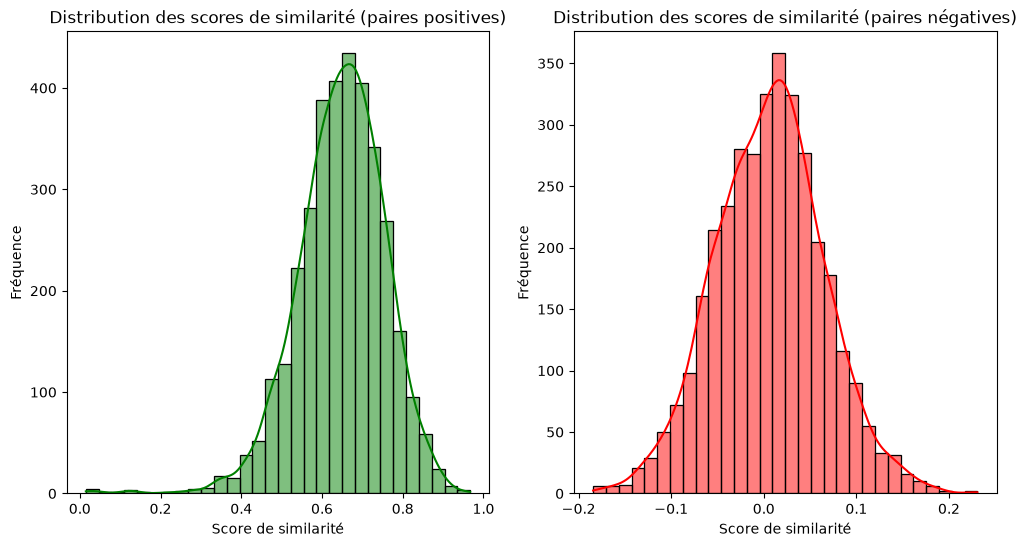

In [15]:
# Calcul de la moyenne et de l'écart-type des scores
positive_scores = np.array(positive_scores)
negative_scores = np.array(negative_scores)

print("Positive scores:")
print(f"  mean: {positive_scores.mean():.4f}")
print(f"  std:  {positive_scores.std():.4f}")
print(f"  min:  {positive_scores.min():.4f}")
print(f"  max:  {positive_scores.max():.4f}")

print("\nNegative scores:")
print(f"  mean: {negative_scores.mean():.4f}")
print(f"  std:  {negative_scores.std():.4f}")
print(f"  min:  {negative_scores.min():.4f}")
print(f"  max:  {negative_scores.max():.4f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(positive_scores, bins=30, kde=True, color='green')
plt.title("Distribution des scores de similarité (paires positives)")
plt.xlabel("Score de similarité")
plt.ylabel("Fréquence")
plt.subplot(1, 2, 2)
sns.histplot(negative_scores, bins=30, kde=True, color='red')
plt.title("Distribution des scores de similarité (paires négatives)")
plt.xlabel("Score de similarité")
plt.ylabel("Fréquence")
plt.show()

AUC : 0.9995
Seuil optimal : 0.2380
À ce seuil → TPR (vrais positifs) : 0.9968, FPR (faux positifs) : 0.0000


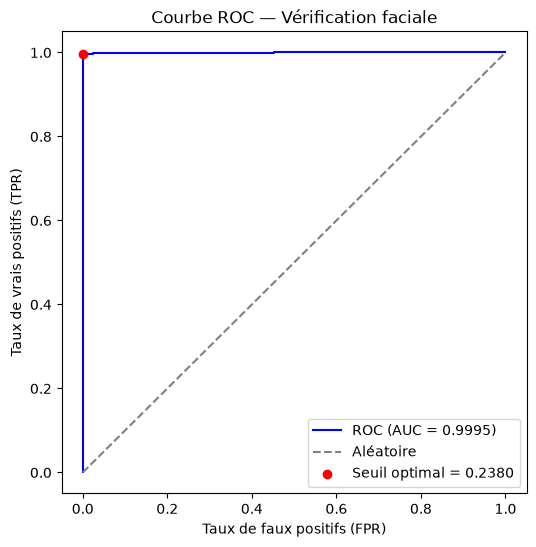

In [16]:
from sklearn.metrics import roc_curve, auc

# Construire les labels et scores combinés
y_true = [1] * len(positive_scores) + [0] * len(negative_scores)
y_scores = list(positive_scores) + list(negative_scores)

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Trouver le seuil optimal (maximise TPR - FPR, aussi appelé indice de Youden)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC : {roc_auc:.4f}")
print(f"Seuil optimal : {optimal_threshold:.4f}")
print(f"À ce seuil → TPR (vrais positifs) : {tpr[optimal_idx]:.4f}, FPR (faux positifs) : {fpr[optimal_idx]:.4f}")

# Visualisation
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aléatoire')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', zorder=5, label=f'Seuil optimal = {optimal_threshold:.4f}')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC — Vérification faciale")
plt.legend()
plt.show()

In [17]:
def verify(image_path1, image_path2, threshold=0.238):
    """
    Vérifie si deux images représentent la même personne.
    Retourne : (bool, score) — True si même personne, False sinon
    """
    score = compare_faces_cached(image_path1, image_path2, verbose=False)
    
    if score is None:
        return None, None
    
    is_same_person = score >= threshold
    return is_same_person, score

In [19]:
match, score = verify(
    "data\\raw\\lfw_funneled\\Clint_Howard\\Clint_Howard_0001.jpg",
    "data\\raw\\lfw_funneled\\Bill_Frist\\Bill_Frist_0006.jpg"
)
print(f"Même personne : {match} (score: {score:.4f})")

Même personne : False (score: -0.0935)


# Vérification 1:N

In [21]:
from pathlib import Path

DATASET_DIR = "data/raw/lfw_funneled"  # adapte selon ton dossier réel

def list_people_with_photos(dataset_dir):
    people = {}
    dataset_path = Path(dataset_dir)
    for person_dir in dataset_path.iterdir():
        if person_dir.is_dir():
            photos = sorted([
                str(p) for p in person_dir.iterdir()
                if p.suffix.lower() in (".jpg", ".jpeg", ".png")
            ])
            if photos:
                people[person_dir.name] = photos
    return people

people = list_people_with_photos(DATASET_DIR)
eligible = {n: p for n, p in people.items() if len(p) >= 2}

print(f"{len(eligible)} personnes avec au moins 2 photos")

1680 personnes avec au moins 2 photos


In [22]:
import faiss

# --- 1. Sélectionner les personnes enrôlées ---
# On prend les mêmes personnes "éligibles" que pour les paires (>= 2 photos)
# pour être sûr d'avoir une photo de référence + une photo de test différente
enrolled_names = list(eligible.keys())[:30]  # 30 premières personnes éligibles

print(f"{len(enrolled_names)} personnes enrôlées")

30 personnes enrôlées


In [23]:
# --- 2. Construire les embeddings de la base (photo de référence = 1ère photo) ---
enrolled_embeddings = []
enrolled_labels = []

for name in enrolled_names:
    ref_photo = eligible[name][0]  # première photo = référence enrôlée
    embedding = get_embedding_cached(ref_photo)
    
    if embedding is not None:
        enrolled_embeddings.append(embedding)
        enrolled_labels.append(name)

enrolled_embeddings = np.array(enrolled_embeddings).astype('float32')
print(f"Base construite : {enrolled_embeddings.shape}")  # attendu : (N, 512)

e:\Reconnaisance_faciale\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Base construite : (30, 512)


In [24]:
# --- 3. Créer l'index FAISS ---
dimension = enrolled_embeddings.shape[1]  # 512
index = faiss.IndexFlatIP(dimension)      # IP = Inner Product (produit scalaire)
index.add(enrolled_embeddings)

print(f"Index créé avec {index.ntotal} vecteurs")

Index créé avec 30 vecteurs


In [25]:
# --- 4. Tester une recherche ---
def identify(image_path, threshold=0.238, k=1):
    """
    Cherche la personne la plus proche dans la base enrôlée.
    Retourne : (nom ou 'Inconnu', score)
    """
    embedding = get_embedding_cached(image_path)
    if embedding is None:
        return None, None
    
    embedding = np.array([embedding]).astype('float32')  # FAISS attend un batch (2D)
    scores, indices = index.search(embedding, k)
    
    best_score = scores[0][0]
    best_idx = indices[0][0]
    
    if best_score < threshold:
        return "Inconnu", best_score
    
    return enrolled_labels[best_idx], best_score

In [50]:
# --- Test ---
test_name = enrolled_names[25]
test_photo = eligible[test_name][1]  # 2ème photo (différente de la référence)

name, score = identify(test_photo)
print(f"Vraie identité : {test_name}")
print(f"Identifié comme : {name} (score: {score:.4f})")

Vraie identité : Akhmed_Zakayev
Identifié comme : Akhmed_Zakayev (score: 0.7541)


In [41]:
print(len(enrolled_names))

30


In [38]:
# Prendre une personne qui n'est PAS dans enrolled_names
unknown_candidates = [n for n in eligible.keys() if n not in enrolled_names]
test_name_unknown = unknown_candidates[0]
test_photo_unknown = eligible[test_name_unknown][0]

name, score = identify(test_photo_unknown)
print(f"Vraie identité (non enrôlée) : {test_name_unknown}")
print(f"Résultat : {name} (score: {score:.4f})")

Vraie identité (non enrôlée) : Alberto_Fujimori
Résultat : Inconnu (score: 0.1102)


In [52]:
# --- Test sur personnes enrôlées ---
correct_identifications = 0
tested_enrolled = 0

for name in enrolled_names:
    if len(eligible[name]) < 2:
        continue  # pas de 2ème photo disponible pour tester
    
    test_photo = eligible[name][1]
    predicted_name, score = identify(test_photo)   # ta fonction du notebook, pas face_db.identify
    
    tested_enrolled += 1
    if predicted_name == name:
        correct_identifications += 1

identification_rate = correct_identifications / tested_enrolled
print(f"Taux d'identification correcte : {identification_rate:.2%} ({correct_identifications}/{tested_enrolled})")

# --- Test sur personnes NON enrôlées ---
unknown_candidates = [n for n in eligible.keys() if n not in enrolled_names]
sample_unknown = unknown_candidates[:50]

correct_rejections = 0
false_acceptances = 0

for name in sample_unknown:
    test_photo = eligible[name][0]
    predicted_name, score = identify(test_photo)
    
    if predicted_name == "Inconnu":
        correct_rejections += 1
    else:
        false_acceptances += 1

rejection_rate = correct_rejections / len(sample_unknown)
false_acceptance_rate = false_acceptances / len(sample_unknown)

print(f"Taux de rejet correct : {rejection_rate:.2%} ({correct_rejections}/{len(sample_unknown)})")
print(f"Taux de fausse acceptation : {false_acceptance_rate:.2%} ({false_acceptances}/{len(sample_unknown)})")

Taux d'identification correcte : 100.00% (30/30)
Taux de rejet correct : 100.00% (50/50)
Taux de fausse acceptation : 0.00% (0/50)
